In [ ]:
#%cd      /media/volume/NOCOS_WRK/ridge  #  change working directory 
NOCOSDIR='/home/ilja/NOCOS_locdev/NOCOS'
import os
os.chdir("/media/volume/NOCOS_WRK/ridge")
print(os.getcwd())  # where are we ?


/media/volume/NOCOS_WRK/ridge


In [2]:
import xarray as xr

url = "https://cacheb.dcms.destine.eu/d1-climate-dt/ScenarioMIP-SSP3-7.0-IFS-NEMO-0001-high-o2d-v0.zarr"
ds = xr.open_dataset(
    url, 
    chunks={}, 
    engine="zarr", 
    storage_options={"client_kwargs": {"trust_env": True}}
)
ds

/home/ubuntu/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


<xarray.Dataset> Size: 4TB
Dimensions:       (time: 3653, latitude: 4096, longitude: 8193)
Coordinates:
  * latitude      (latitude) float64 33kB -90.0 -89.96 -89.91 ... 89.96 90.0
  * longitude     (longitude) float64 66kB -180.0 -180.0 -179.9 ... 180.0 180.0
    oceanSurface  float64 8B ...
    step          timedelta64[ns] 8B ...
  * time          (time) datetime64[ns] 29kB 2020-01-01 ... 2029-12-31
Data variables:
    avg_siconc    (time, latitude, longitude) float32 490GB dask.array<chunksize=(60, 256, 256), meta=np.ndarray>
    avg_sithick   (time, latitude, longitude) float32 490GB dask.array<chunksize=(60, 256, 256), meta=np.ndarray>
    avg_siue      (time, latitude, longitude) float32 490GB dask.array<chunksize=(60, 256, 256), meta=np.ndarray>
    avg_sivn      (time, latitude, longitude) float32 490GB dask.array<chunksize=(60, 256, 256), meta=np.ndarray>
    avg_sivol     (time, latitude, longitude) float32 490GB dask.array<chunksize=(60, 256, 256), meta=np.ndarray>
    avg_sos       (time, latitude, longitude) float32 490GB dask.array<chunksize=(60, 256, 256), meta=np.ndarray>
    avg_tos       (time, latitude, longitude) float32 490GB dask.array<chunksize=(60, 256, 256), meta=np.ndarray>
    avg_zos       (time, latitude, longitude) float32 490GB dask.array<chunksize=(60, 256, 256), meta=np.ndarray>
Attributes:
    Conventions:             CF-1.7
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_edition:            2
    GRIB_subCentre:          1003
    history:                 2024-05-30T05:51 GRIB to CDM+CF via cfgrib-0.9.1...
    institution:             European Centre for Medium-Range Weather Forecasts

In [3]:
import xarray as xr

url = "https://cacheb.dcms.destine.eu/d1-climate-dt/ScenarioMIP-SSP3-7.0-IFS-NEMO-0001-high-o2d-v0.zarr"
ds = xr.open_dataset(
    url, 
    chunks={}, 
    engine="zarr", 
    storage_options={"client_kwargs": {"trust_env": True}}
)


,Array,Chunk
Bytes,456.68 GiB,15.00 MiB
Shape,"(3653, 4096, 8193)","(60, 256, 256)"
Count,32209 Tasks,32208 Chunks
Type,float32,numpy.ndarray
,Array,Chunk
Bytes,456.68 GiB,15.00 MiB
Shape,"(3653, 4096, 8193)","(60, 256, 256)"
Count,32209 Tasks,32208 Chunks
Type,float32,numpy.ndarray
,Array,Chunk


In [2]:
import matplotlib.colors as mcolors
import numpy as np
import matplotlib.pyplot as plt

original_cmap = plt.cm.Purples
colors = original_cmap(np.linspace(0.1, 1.0, 256))  # Exclude the first 10% of the colormap
colors[0] = [1, 1, 1, 1]  # Set the last color to white (RGBA)
new_cmap = mcolors.LinearSegmentedColormap.from_list("Purples_truncated", colors)
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

This is Markdown note _dsadA_  
--
**this is bold**

In [2]:

import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cf
from datetime import datetime


# Define the variables for the selection
lon1, lon2 = 9, 30  # Longitude range
lat1, lat2 = 53, 66  # Latitude range
start_date = "2024-11-01"  # Start date
end_date = "2025-05-31"  # End date

# Select the data using the variables
ds_t_reg = ds.sel(
    **{"latitude": slice(lat1, lat2), "longitude": slice(lon1, lon2)}
).sel(time=slice(start_date, end_date))

# The rest of the code remains unchanged

# Apply the conditions for masking
# Ridging:  Thick ice  and has voids (0.3) due to porosity of ridges 
masked_data = ds_t_reg.where(
    (ds_t_reg.avg_sithick > 0.5) & 
    (ds_t_reg.avg_siconc > 0.975) & 
    (ds_t_reg.avg_siconc <= 0.999)
)
#masked_data = ds_t_reg.where(
#    (ds_t_reg.avg_sithick > 0.5) & 
#    (ds_t_reg.avg_siconc > 0.975) & 
#    (ds_t_reg.avg_siconc <= 0.3)
#)

# Calculate the number of days between the two dates
start = datetime.strptime(start_date, "%Y-%m-%d")
end = datetime.strptime(end_date, "%Y-%m-%d")
num_days = (end - start).days
# Count the number of days meeting the condition for each spatial point
rid_prob = masked_data.avg_siconc.count(dim="time")/num_days

# Create the plot
ax = plt.axes(projection=ccrs.Mercator())
rid_prob.plot(
    ax=ax,
    transform=ccrs.PlateCarree(),
    cmap=new_cmap, vmax=0.15,
    cbar_kwargs={"label": "Ridged ice probability"} 
)

# Set plot extent and features
#ax.set_extent([22, 26, 57, 60], crs=ccrs.PlateCarree())
#plt.title(" P (avg_sithick > 0.5 and 0.975 < avg_siconc <= 0.999)")
ax.coastlines(color=(0.7, 0.7, 0.7))
ax.add_feature(cf.BORDERS,color=(0.7, 0.7, 0.7))

from matplotlib.offsetbox import OffsetImage, AnnotationBbox
# Load the logo and place it in the lower left corner
logo_path = f"{NOCOSDIR}/logos/NOCOS-DT_logo_RGB_fullcolour.png"
logo = plt.imread(logo_path)
imagebox = OffsetImage(logo, zoom=0.08)  # Adjust zoom for size
ab = AnnotationBbox(imagebox, (0.23, 0.95), frameon=False, xycoords="axes fraction")
ax.add_artist(ab)
# Show the plot
plt.show()

NameError: name 'ds' is not defined

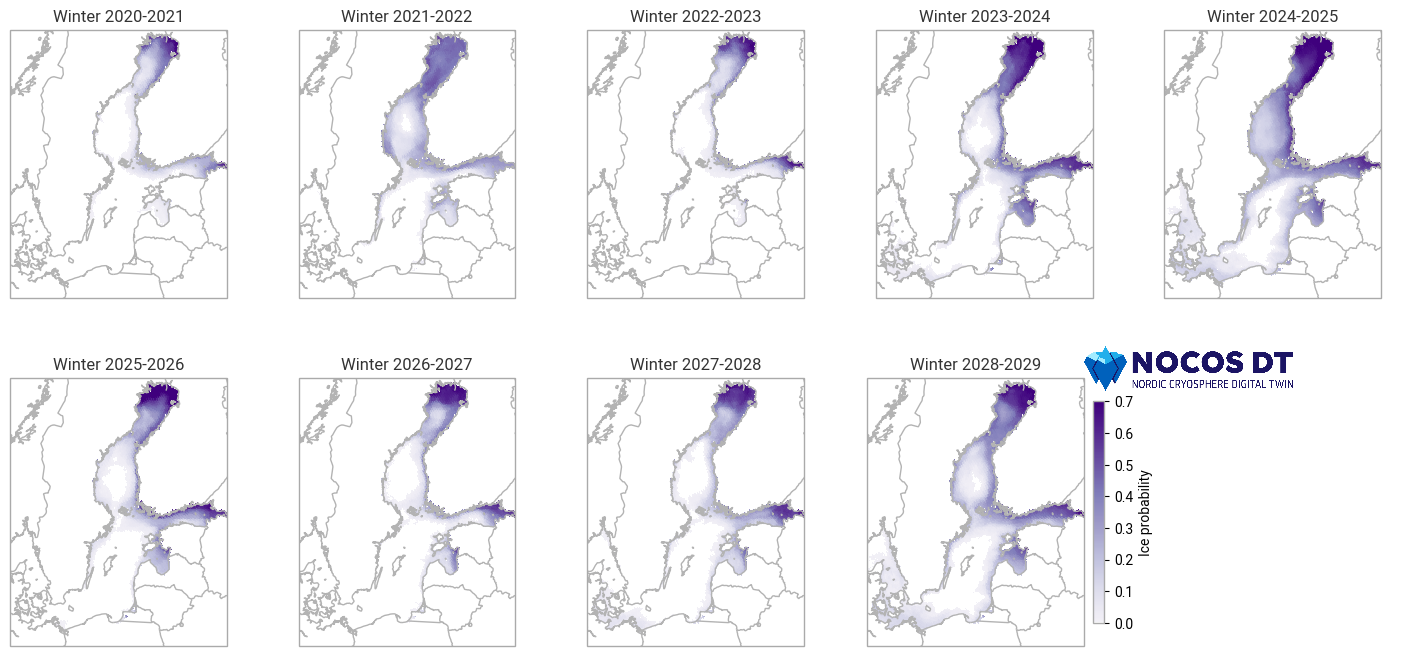

In [5]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cf
from datetime import datetime
import xarray as xr
import numpy as np
from matplotlib.colors import ListedColormap
from matplotlib.offsetbox import OffsetImage, AnnotationBbox

# Define the variables for the selection
lon1, lon2 = 9, 30  # Longitude range
lat1, lat2 = 53, 66  # Latitude range
start_month, start_day = 11, 1  # Winter start date (Nov 1)
end_month, end_day = 5, 31  # Winter end date (May 31)

years = range(2020, 2029)  # Loop over years

# Define a custom colormap
original_cmap = plt.cm.Purples
colors = original_cmap(np.linspace(0.1, 1.0, 256))  # Exclude the first 10% of the colormap
colors[0] = [1, 1, 1, 1]  # Set the last color to white (RGBA)
new_cmap = ListedColormap(colors)

# Create a 2x5 subplot figure
fig, axs = plt.subplots(2, 5, figsize=(18, 8), subplot_kw={'projection': ccrs.Mercator()}, gridspec_kw={"wspace": 0.2, "hspace": 0.3})
axs = axs.flatten()

# Switch variable to toggle masking conditions
masking_option = 3  # Set to 1, 2, or 3 to choose masking condition

# Store the colorbar to add it only to the last subplot
colorbar = None

for idx, year in enumerate(years):
    # Define the winter start and end dates for each year
    start_date = f"{year}-{start_month:02d}-{start_day:02d}"
    end_date = f"{year + 1}-{end_month:02d}-{end_day:02d}"

    # Select the data using the variables
    ds_t_reg = ds.sel(
        **{"latitude": slice(lat1, lat2), "longitude": slice(lon1, lon2)}
    ).sel(time=slice(start_date, end_date))

    # Apply the conditions for masking based on the masking option
    if masking_option == 1:
        vm=0.15;clab="Ridged ice probability"
        masked_data = ds_t_reg.where(
            (ds_t_reg.avg_sithick > 0.5) &   # thick ice  
            (ds_t_reg.avg_siconc > 0.975) &  # porosity
            (ds_t_reg.avg_siconc <= 0.999)   # porosity  
        )
    elif masking_option == 2:
        vm=0.05;clab="Rotten ice probability"
        masked_data = ds_t_reg.where(
            (ds_t_reg.avg_sithick > 0.5) & 
            (ds_t_reg.avg_siconc <= 0.3)  # 
        )
    elif masking_option == 3:
        vm=0.7;clab="Ice probability"
        masked_data = ds_t_reg.where(
            (ds_t_reg.avg_siconc > 0.15)  # ICe detection threshold
        )

    # Calculate the number of days in the winter period
    start = datetime.strptime(start_date, "%Y-%m-%d")
    end = datetime.strptime(end_date, "%Y-%m-%d")
    num_days = (end - start).days

    # Calculate ridged ice probability
    rid_prob = masked_data.avg_siconc.count(dim="time") / num_days

    # Create the plot in the corresponding subplot
    ax = axs[idx]
    im = rid_prob.plot(
        ax=ax,
        transform=ccrs.PlateCarree(),
        cmap=new_cmap, vmax=vm,
        add_colorbar=False
    )

    # Add the colorbar only to the last subplot
    if idx == len(years) - 1:
        colorbar = fig.colorbar(im, ax=ax, orientation="vertical", fraction=0.046, pad=0.04)
        colorbar.set_label(clab)
 # Add the colorbar only to the last subplot
    # Set plot extent and features
    ax.set_extent([lon1, lon2, lat1, lat2], crs=ccrs.PlateCarree())
    ax.coastlines(color=(0.7, 0.7, 0.7))
    ax.add_feature(cf.BORDERS, color=(0.7, 0.7, 0.7))

    # Set title with the year range
    ax.set_title(f"Winter {year}-{year + 1}")

# Add the logo to the last subplot
ax = axs[idx+1]
logo_path = f"{NOCOSDIR}/logos/NOCOS-DT_logo_RGB_fullcolour.png"
logo = plt.imread(logo_path)
imagebox = OffsetImage(logo, zoom=0.1)  # Adjust zoom for size
ab = AnnotationBbox(imagebox, (0.15, 1.2), frameon=False, xycoords="axes fraction")
ax.add_artist(ab)
# Remove borders (spines)
for spine in ax.spines.values():
    spine.set_visible(False)

# Optional: Customize ticks or labels if needed
ax.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)

## Example data (optional)
#ax.plot([1, 2, 3], [4, 5, 6])

# Adjust layout and show the plot
plt.tight_layout()
plt.show()
